# Imports

In [3]:
import numpy as np
import pandas as pd
import folium
from deepki.http.api_utils import make_heatwaves, make_precipitations
from deepki.ddk.query import Query
import matplotlib.pyplot as plt
from tqdm import tqdm

colors = ["#007500", "#00D100", "#8AFF8A", "#FFFF00", "#FFA500", "#FF0000"]
pd.set_option('display.max_columns', None)

# Fetching data

In [52]:
project = "primonial"

In [53]:
buildings_df = Query(
    "prod",
    fields=[
        "*",
    ],
    collection="buildings",
    filters={"project_id": [project]},
    exclude={},
).compute()

buildings_df = buildings_df[buildings_df["current_perimeter"]]
buildings_df = buildings_df.reset_index(drop = True)

INFO:deepki.ddk.query:Loading data for projects in platform https://deepki-ready.deepki.com 


  0%|          | 0/1 [00:00<?, ?it/s]

INFO:deepki.ddk.query:Loading data for projects in platform https://esg.realassets.axa-im.com 


0it [00:00, ?it/s]

INFO:deepki.ddk.query:Loading data for projects in platform https://osfi.deepki.com 


0it [00:00, ?it/s]

INFO:deepki.ddk.query:Loading data for projects in platform https://ccs.deepki.com 


0it [00:00, ?it/s]

In [54]:
buildings_df.to_csv("primonial_0910.csv", sep=";")

In [5]:
buildings_df.shape

(1021, 226)

# Precipitations

In [9]:
list_results_rcp45 = []
list_results_rcp85 = []
list_results_ssp245 = []
list_results_ssp585 = []

for lat_val, lon_val in tqdm(zip(buildings_df.lat.values, buildings_df.lon.values)):
        
    dic_results_rcp45 = {"lat" : lat_val, "lon" : lon_val, "collection_name":"precipitations_rcp45"}
    list_results_rcp45.append(dic_results_rcp45)
    dic_results_rcp85 = {"lat" : lat_val, "lon" : lon_val, "collection_name":"precipitations_rcp85"}
    list_results_rcp85.append(dic_results_rcp85)
    dic_results_ssp245 = {"lat" : lat_val, "lon" : lon_val, "collection_name":"precipitations_world_ssp245"}
    list_results_ssp245.append(dic_results_ssp245)
    dic_results_ssp585 = {"lat" : lat_val, "lon" : lon_val, "collection_name":"precipitations_world_ssp585"}
    list_results_ssp585.append(dic_results_ssp585)

results_rcp45 = pd.DataFrame(make_precipitations(inputs=list_results_rcp45))
results_rcp85 = pd.DataFrame(make_precipitations(inputs=list_results_rcp85))
results_ssp245 = pd.DataFrame(make_precipitations(inputs=list_results_ssp245))
results_ssp585 = pd.DataFrame(make_precipitations(inputs=list_results_ssp585))

1021it [00:00, 571060.73it/s]


In [12]:
results_ssp245.columns

Index(['building_mapping', 'collection_name', 'continent', 'continuous_score',
       'data_source', 'discrete_score', 'lat_building', 'latitude',
       'lon_building', 'longitude', 'nmb_xtr_days', 'position',
       'rain_xtr_days'],
      dtype='object')

# Merging and processing data

In [19]:
summary_df = pd.merge(buildings_df[["building_id", "building_name", "lat", "lon", "city", "country", "address"]],
                      results_rcp45[["continuous_score_precipitations", "discrete_score_precipitations", "lat_building", "lon_building"]],
                      how = "left",
                      left_on = ["lat", "lon"],
                      right_on = ["lat_building", "lon_building"])

summary_df = summary_df.drop_duplicates()

summary_df["rank_rcp45"] = summary_df['continuous_score_precipitations'].rank(method='min')

In [20]:
summary_df.head(2)

,building_id,building_name,lat,lon,city,country,address,continuous_score_precipitations,discrete_score_precipitations,lat_building,lon_building,rank_rcp45
0,I0014,I0014 - NEUILLY 179 CDG,48.883845,2.262274,NEUILLY-SUR-SEINE,france,179-181 avenue Charles De Gaulle,57.944788,1,48.883845,2.262274,372.0
1,I0181,I0181 - MONTREUIL ATLAS,48.849477,2.419210,Montreuil,france,118 Rue de Lagny,57.944788,1,48.849477,2.419210,372.0


In [21]:
summary_df = pd.merge(summary_df,
                      results_rcp85[["continuous_score_precipitations", "discrete_score_precipitations", "lat_building", "lon_building"]],
                      how = "left",
                      on = ["lat_building", "lon_building"],
                      suffixes = ("_rcp45", "_rcp85")
                     )

summary_df = summary_df.drop_duplicates()

summary_df["rank_rcp85"] = summary_df['continuous_score_precipitations_rcp85'].rank(method='min')

In [22]:
summary_df.head(2)

,building_id,building_name,lat,lon,city,country,address,continuous_score_precipitations_rcp45,discrete_score_precipitations_rcp45,lat_building,lon_building,rank_rcp45,continuous_score_precipitations_rcp85,discrete_score_precipitations_rcp85,rank_rcp85
0,I0014,I0014 - NEUILLY 179 CDG,48.883845,2.262274,NEUILLY-SUR-SEINE,france,179-181 avenue Charles De Gaulle,57.944788,1,48.883845,2.262274,372.0,106.528734,1,95.0
1,I0181,I0181 - MONTREUIL ATLAS,48.849477,2.419210,Montreuil,france,118 Rue de Lagny,57.944788,1,48.849477,2.419210,372.0,106.528734,1,95.0


In [23]:
summary_df = pd.merge(summary_df,
                      results_ssp245[['continuous_score', 'discrete_score', 'nmb_xtr_days', 'rain_xtr_days', "lat_building", "lon_building"]],
                      how = "left",
                      on = ["lat_building", "lon_building"],
                     )

summary_df = summary_df.drop_duplicates()

summary_df["rank_ssp245"] = summary_df['continuous_score'].rank(method='min')

In [24]:
summary_df.head(2)

,building_id,building_name,lat,lon,city,country,address,continuous_score_precipitations_rcp45,discrete_score_precipitations_rcp45,lat_building,lon_building,rank_rcp45,continuous_score_precipitations_rcp85,discrete_score_precipitations_rcp85,rank_rcp85,continuous_score,discrete_score,nmb_xtr_days,rain_xtr_days,rank_ssp245
0,I0014,I0014 - NEUILLY 179 CDG,48.883845,2.262274,NEUILLY-SUR-SEINE,france,179-181 avenue Charles De Gaulle,57.944788,1,48.883845,2.262274,372.0,106.528734,1,95.0,19.271336,2.0,16.390476,78.488783,49.0
1,I0181,I0181 - MONTREUIL ATLAS,48.849477,2.419210,Montreuil,france,118 Rue de Lagny,57.944788,1,48.849477,2.419210,372.0,106.528734,1,95.0,19.271336,2.0,16.390476,78.488783,49.0


In [25]:
summary_df = pd.merge(summary_df,
                      results_ssp585[['continuous_score', 'discrete_score', 'nmb_xtr_days', 'rain_xtr_days', "lat_building", "lon_building"]],
                      how = "left",
                      on = ["lat_building", "lon_building"],
                      suffixes = ("_ssp245", "_ssp585")
                     )

summary_df = summary_df.drop_duplicates().drop(columns = ["lat_building", "lon_building"])

summary_df["rank_ssp585"] = summary_df['continuous_score_ssp585'].rank(method='min')

In [27]:
summary_df.head(2)

,building_id,building_name,lat,lon,city,country,address,continuous_score_precipitations_rcp45,discrete_score_precipitations_rcp45,rank_rcp45,continuous_score_precipitations_rcp85,discrete_score_precipitations_rcp85,rank_rcp85,continuous_score_ssp245,discrete_score_ssp245,nmb_xtr_days_ssp245,rain_xtr_days_ssp245,rank_ssp245,continuous_score_ssp585,discrete_score_ssp585,nmb_xtr_days_ssp585,rain_xtr_days_ssp585,rank_ssp585
0,I0014,I0014 - NEUILLY 179 CDG,48.883845,2.262274,NEUILLY-SUR-SEINE,france,179-181 avenue Charles De Gaulle,57.944788,1,372.0,106.528734,1,95.0,19.271336,2.0,16.390476,78.488783,49.0,18.839316,2.0,16.12381,54.21343,47.0
1,I0181,I0181 - MONTREUIL ATLAS,48.849477,2.419210,Montreuil,france,118 Rue de Lagny,57.944788,1,372.0,106.528734,1,95.0,19.271336,2.0,16.390476,78.488783,49.0,18.839316,2.0,16.12381,54.21343,47.0


In [30]:
summary_df["diff_rank_ssp245_rcp45"] = summary_df["rank_ssp245"] - summary_df["rank_rcp45"]
summary_df["diff_rank_ssp585_rcp85"] = summary_df["rank_ssp585"] - summary_df["rank_rcp85"]

summary_df["diff_discrete_score_ssp245_rcp45"] = summary_df["discrete_score_ssp245"] - summary_df["discrete_score_precipitations_rcp45"]
summary_df["diff_discrete_score_ssp585_rcp85"] = summary_df["discrete_score_ssp585"] - summary_df["discrete_score_precipitations_rcp85"]

# Results

## Change in raking among project's assets

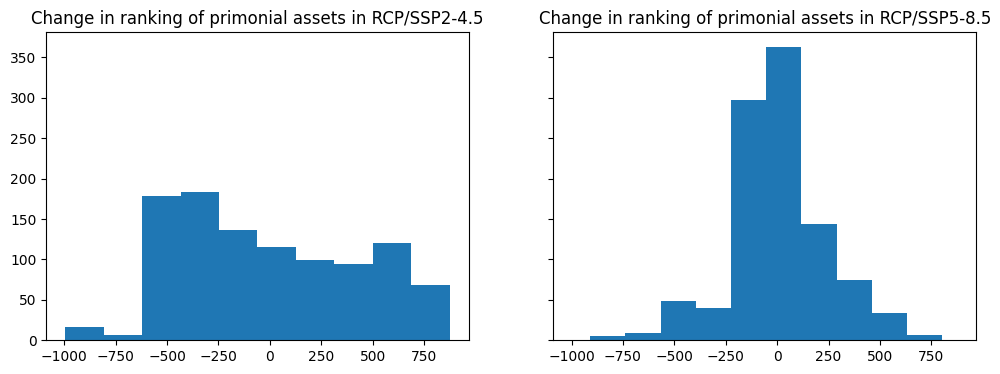

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4), sharex = True, sharey = True)

ax1.hist(summary_df["diff_rank_ssp245_rcp45"])
ax1.set_title(f"Change in ranking of {project} assets in RCP/SSP2-4.5")
ax2.hist(summary_df["diff_rank_ssp585_rcp85"])
ax2.set_title(f"Change in ranking of {project} assets in RCP/SSP5-8.5");

In [32]:
nb_bdgs = len(summary_df)
print(f"Split of change in ranking for {project} assets in RCP/SSP2-4.5 scenario")
summary_df['magnitude_of_ranking_chg_ssp245_rcp45'] = pd.cut(summary_df['diff_rank_ssp245_rcp45'], bins=[-nb_bdgs, -nb_bdgs/2, -nb_bdgs/10, nb_bdgs/10, nb_bdgs/2, nb_bdgs], labels = ["High decrease in raking", "Moderate decrease in raking", "Stable ranking", "Moderate increase in raking", "High increase in raking"], right=True)
summary_df['magnitude_of_ranking_chg_ssp245_rcp45'].value_counts()

Split of change in ranking for primonial assets in RCP/SSP2-4.5 scenario


Moderate decrease in raking    471
Moderate increase in raking    209
High increase in raking        186
Stable ranking                 119
High decrease in raking         36
Name: magnitude_of_ranking_chg_ssp245_rcp45, dtype: int64

In [33]:
print(f"Split of change in ranking for {project} assets in RCP/SSP5-8.5 scenario")
summary_df['magnitude_of_ranking_chg_ssp585_rcp85'] = pd.cut(summary_df['diff_rank_ssp585_rcp85'], bins=[-nb_bdgs, -nb_bdgs/2, -nb_bdgs/10, nb_bdgs/10, nb_bdgs/2, nb_bdgs], labels = ["High decrease in raking", "Moderate decrease in raking", "Stable ranking", "Moderate increase in raking", "High increase in raking"], right=True)
summary_df['magnitude_of_ranking_chg_ssp585_rcp85'].value_counts()

Split of change in ranking for primonial assets in RCP/SSP5-8.5 scenario


Stable ranking                 579
Moderate increase in raking    232
Moderate decrease in raking    152
High increase in raking         34
High decrease in raking         24
Name: magnitude_of_ranking_chg_ssp585_rcp85, dtype: int64

In [35]:
m = folium.Map(location = (48.02134766687152, 12.877171825314177), zoom_start = 4)

for i, row in summary_df[summary_df['magnitude_of_ranking_chg_ssp245_rcp45'] != 'Stable raking'].iterrows():
    if row.magnitude_of_ranking_chg_ssp245_rcp45 == 'High decrease in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#007500",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp245)) + "<br> Old ranking: " + str(int(row.rank_rcp45))).add_to(m)

    if row.magnitude_of_ranking_chg_ssp245_rcp45 == 'Moderate decrease in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#00D100",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp245)) + "<br> Old ranking: " + str(int(row.rank_rcp45))).add_to(m)

    if row.magnitude_of_ranking_chg_ssp245_rcp45 == 'Moderate increase in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#FFA500",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp245)) + "<br> Old ranking: " + str(int(row.rank_rcp45))).add_to(m)
    
    if row.magnitude_of_ranking_chg_ssp245_rcp45 == 'High increase in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#FF0000",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp245)) + "<br> Old ranking: " + str(int(row.rank_rcp45))).add_to(m)
        
m.save(f"./{project}_greatest_change_in_ranking_ssp245_rcp45.html")
m

In [36]:
m = folium.Map(location = (48.02134766687152, 12.877171825314177), zoom_start = 4)

for i, row in summary_df[summary_df['magnitude_of_ranking_chg_ssp585_rcp85'] != 'Stable raking'].iterrows():
    if row.magnitude_of_ranking_chg_ssp585_rcp85 == 'High decrease in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#007500",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp585)) + "<br> Old ranking: " + str(int(row.rank_rcp85))).add_to(m)

    if row.magnitude_of_ranking_chg_ssp585_rcp85 == 'Moderate decrease in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#00D100",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp585)) + "<br> Old ranking: " + str(int(row.rank_rcp85))).add_to(m)

    if row.magnitude_of_ranking_chg_ssp585_rcp85 == 'Moderate increase in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#FFA500",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp585)) + "<br> Old ranking: " + str(int(row.rank_rcp85))).add_to(m)
    
    if row.magnitude_of_ranking_chg_ssp585_rcp85 == 'High increase in raking':
        folium.Circle(location = (row.lat, row.lon),
                     color = "#FF0000",
                     popup = "Building id: " + str(row.building_id) + "<br> New ranking: " + str(int(row.rank_ssp585)) + "<br> Old ranking: " + str(int(row.rank_rcp85))).add_to(m)
        
m.save(f"./{project}_greatest_change_in_ranking_ssp585_rcp85.html")
m

## Change in discrete scores

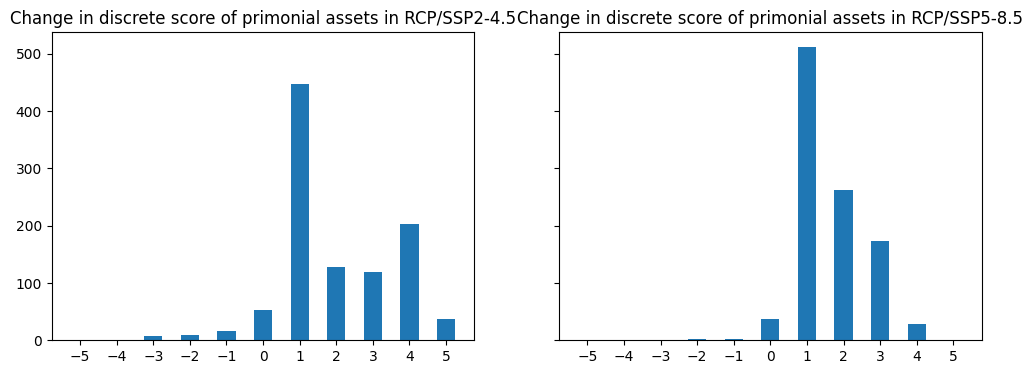

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4), sharex = True, sharey = True)

ax1.hist(summary_df["diff_discrete_score_ssp245_rcp45"], bins = np.linspace(-5.5, 5.5, 12), rwidth = 0.5)
ax1.set_title(f"Change in discrete score of {project} assets in RCP/SSP2-4.5")
ax1.set_xticks(np.linspace(-5, 5, 11))

ax2.hist(summary_df["diff_discrete_score_ssp585_rcp85"], bins = np.linspace(-5.5, 5.5, 12), rwidth = 0.5)
ax2.set_title(f"Change in discrete score of {project} assets in RCP/SSP5-8.5")
ax2.set_xticks(np.linspace(-5, 5, 11));

In [38]:
print(f"Split of change in discrete score for {project} assets in RCP/SSP2-4.5 scenario")
summary_df['magnitude_of_discrete_score_chg_ssp245_rcp45'] = pd.cut(summary_df['diff_discrete_score_ssp245_rcp45'], bins=[-5.5, -3.5, -1.5, 1.5, 3.5, 5.5], labels = ["High decrease in discrete score (-4 or -5 pts)", "Moderate decrease in discrete score (-2 or -3 pts)", "Stable discrete score (-1, +1 pt or no change)", "Moderate increase in discrete score (+2 or +3 pts)", "High increase in discrete score (+4 or +5 pts)"], right=True)
summary_df['magnitude_of_discrete_score_chg_ssp245_rcp45'].value_counts()

Split of change in discrete score for primonial assets in RCP/SSP2-4.5 scenario


Stable discrete score (-1, +1 pt or no change)        517
Moderate increase in discrete score (+2 or +3 pts)    247
High increase in discrete score (+4 or +5 pts)        241
Moderate decrease in discrete score (-2 or -3 pts)     16
High decrease in discrete score (-4 or -5 pts)          0
Name: magnitude_of_discrete_score_chg_ssp245_rcp45, dtype: int64

In [39]:
print(f"Percentage of assets whose discrete score remains stable for {project} in SSP2-4.5 scenario: {round(len(summary_df[summary_df['magnitude_of_discrete_score_chg_ssp245_rcp45'] == 'Stable discrete score (-1, +1 pt or no change)'])/len(summary_df)*100,1)}%")

Percentage of assets whose discrete score remains stable for primonial in SSP2-4.5 scenario: 50.6%


In [40]:
summary_df['diff_discrete_score_ssp245_rcp45'].value_counts()

 1.0    447
 4.0    203
 2.0    128
 3.0    119
 0.0     53
 5.0     38
-1.0     17
-2.0      9
-3.0      7
Name: diff_discrete_score_ssp245_rcp45, dtype: int64

In [41]:
print(f"Split of change in discrete score for {project} assets in RCP/SSP5-8.5 scenario")
summary_df['magnitude_of_discrete_score_chg_ssp585_rcp85'] = pd.cut(summary_df['diff_discrete_score_ssp585_rcp85'], bins=[-5.5, -3.5, -1.5, 1.5, 3.5, 5.5], labels = ["High decrease in discrete score (-4 or -5 pts)", "Moderate decrease in discrete score (-2 or -3 pts)", "Stable discrete score (-1, +1 pt or no change)", "Moderate increase in discrete score (+2 or +3 pts)", "High increase in discrete score (+4 or +5 pts)"], right=True)
summary_df['magnitude_of_discrete_score_chg_ssp585_rcp85'].value_counts()

Split of change in discrete score for primonial assets in RCP/SSP5-8.5 scenario


Stable discrete score (-1, +1 pt or no change)        553
Moderate increase in discrete score (+2 or +3 pts)    436
High increase in discrete score (+4 or +5 pts)         29
Moderate decrease in discrete score (-2 or -3 pts)      3
High decrease in discrete score (-4 or -5 pts)          0
Name: magnitude_of_discrete_score_chg_ssp585_rcp85, dtype: int64

In [42]:
print(f"Percentage of assets whose discrete score remains stable for {project} in SSP5-8.5 scenario: {round(len(summary_df[summary_df['magnitude_of_discrete_score_chg_ssp585_rcp85'] == 'Stable discrete score (-1, +1 pt or no change)'])/len(summary_df)*100,1)}%")

Percentage of assets whose discrete score remains stable for primonial in SSP5-8.5 scenario: 54.2%


In [44]:
loc = 'Magnitude of changes in precipitations discrete scores for Primonial assets in SSP2-4.5 scenario'
title_html = '''
             <h3 align="center" style="font-size:16px"><b>{}</b></h3>
             '''.format(loc)   


m = folium.Map(location = (48.02134766687152, 12.877171825314177), zoom_start = 5)

#Defining groups:
stable = folium.FeatureGroup(name="Stable discrete score (0 or +/-1 pt)").add_to(m)
moderate_change = folium.FeatureGroup(name="Moderate change in discrete score (+/-2 or 3 pts)").add_to(m)
high_change = folium.FeatureGroup(name="High change in discrete score (+/-4 or 5 pts)").add_to(m)

for i, row in summary_df.iterrows():
    
    if row.magnitude_of_discrete_score_chg_ssp245_rcp45 in ['Stable discrete score (-1, +1 pt or no change)']:        
        stable.add_child(folium.Circle(location = (row.lat, row.lon),
                     color = "darkgreen",
                     popup = "Building id: " + str(row.building_id) + "<br> New disc. score: " + str(int(row.discrete_score_ssp245)) + "<br> Old disc. score: " + str(int(row.discrete_score_precipitations_rcp45))))

    elif row.magnitude_of_discrete_score_chg_ssp245_rcp45 in ['Moderate decrease in discrete score (-2 or -3 pts)', 'Moderate increase in discrete score (+2 or +3 pts)']:        
        moderate_change.add_child(folium.Circle(location = (row.lat, row.lon),
                     color = "blue",
                     popup = "Building id: " + str(row.building_id) + "<br> New disc. score: " + str(int(row.discrete_score_ssp245)) + "<br> Old disc. score: " + str(int(row.discrete_score_precipitations_rcp45))))
        
    elif row.magnitude_of_discrete_score_chg_ssp245_rcp45 in ['High decrease in discrete score (-4 or -5 pts)', 'High increase in discrete score (+4 or +5 pts)']:
        high_change.add_child(folium.Circle(location = (row.lat, row.lon),
                     color = "fuchsia",
                     popup = "Building id: " + str(row.building_id) + "<br> New disc. score: " + str(int(row.discrete_score_ssp245)) + "<br> Old disc. score: " + str(int(row.discrete_score_precipitations_rcp45))))        

folium.LayerControl().add_to(m)
m.get_root().html.add_child(folium.Element(title_html))

m.save(f"./{project}_greatest_change_in_discrete_score_ssp245_rcp45.html")
m

In [45]:
loc = 'Magnitude of changes in precipitations discrete scores for Primonial assets in SSP5-8.5 scenario'
title_html = '''
             <h3 align="center" style="font-size:16px"><b>{}</b></h3>
             '''.format(loc)   


m = folium.Map(location = (48.02134766687152, 12.877171825314177), zoom_start = 5)

#Defining groups:
stable = folium.FeatureGroup(name="Stable discrete score (0 or +/-1 pt)").add_to(m)
moderate_change = folium.FeatureGroup(name="Moderate change in discrete score (+/-2 or 3 pts)").add_to(m)
high_change = folium.FeatureGroup(name="High change in discrete score (+/-4 or 5 pts)").add_to(m)

for i, row in summary_df.iterrows():
    
    if row.magnitude_of_discrete_score_chg_ssp585_rcp85 in ['Stable discrete score (-1, +1 pt or no change)']:        
        stable.add_child(folium.Circle(location = (row.lat, row.lon),
                     color = "darkgreen",
                     popup = "Building id: " + str(row.building_id) + "<br> New disc. score: " + str(int(row.discrete_score_ssp585)) + "<br> Old disc. score: " + str(int(row.discrete_score_precipitations_rcp85))))

    elif row.magnitude_of_discrete_score_chg_ssp585_rcp85 in ['Moderate decrease in discrete score (-2 or -3 pts)', 'Moderate increase in discrete score (+2 or +3 pts)']:        
        moderate_change.add_child(folium.Circle(location = (row.lat, row.lon),
                     color = "blue",
                     popup = "Building id: " + str(row.building_id) + "<br> New disc. score: " + str(int(row.discrete_score_ssp585)) + "<br> Old disc. score: " + str(int(row.discrete_score_precipitations_rcp85))))
        
    elif row.magnitude_of_discrete_score_chg_ssp585_rcp85 in ['High decrease in discrete score (-4 or -5 pts)', 'High increase in discrete score (+4 or +5 pts)']:
        high_change.add_child(folium.Circle(location = (row.lat, row.lon),
                     color = "fuchsia",
                     popup = "Building id: " + str(row.building_id) + "<br> New disc. score: " + str(int(row.discrete_score_ssp585)) + "<br> Old disc. score: " + str(int(row.discrete_score_precipitations_rcp85))))        

folium.LayerControl().add_to(m)
m.get_root().html.add_child(folium.Element(title_html))

m.save(f"./{project}_greatest_change_in_discrete_score_ssp585_rcp85.html")
m

# Saving summary excel

In [46]:
summary_df = summary_df.reset_index(drop = True)
summary_df.to_excel(f"./{project}_summary_precipitations_change.xlsx")

In [48]:
list_results_ssp245 = []
list_results_ssp585 = []

for lat_val, lon_val in tqdm(zip(buildings_df.lat.values, buildings_df.lon.values)):
        
    dic_results_ssp245 = {"lat" : lat_val, "lon" : lon_val, "collection_name":"clay_subsidence_ssp245"}
    list_results_ssp245.append(dic_results_ssp245)
    dic_results_ssp585 = {"lat" : lat_val, "lon" : lon_val, "collection_name":"clay_subsidence_ssp585"}
    list_results_ssp585.append(dic_results_ssp585)

results_ssp245 = pd.DataFrame(make_clay_subsidence(inputs=list_results_ssp245))
results_ssp585 = pd.DataFrame(make_clay_subsidence(inputs=list_results_ssp585))

1021it [00:00, 95490.89it/s]


NameError: name 'make_clay_subsidence' is not defined